## Surgical Phase Recognition with Video Action Transformers

### Project Goal

#### Build a system that:

1. Detects human skeletal keypoints from video (MediaPipe / YOLO-Pose)

2. Models the temporal sequence of poses

3. Recognizes the current surgical phase (or industrial action phase)

4. Optionally scores ergonomic risk / deviation from protocol

5. Shows a live timeline dashboard

## Phase 1: Data Acquisition, Exploration & Visualization

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import random
import seaborn as sns
import warnings

from PIL import Image
from collections import Counter, defaultdict
from IPython.display import display, Markdown

warnings.filterwarnings('ignore')

ROOT = '/kaggle/input/datasets/ganumatta/cholec80'
FRAMES_DIR = os.path.join(ROOT, 'frames')
PHASE_DIR = os.path.join(ROOT, 'phase_annotations')
TOOL_DIR = os.path.join(ROOT, 'tool_annotations')

print('Root exists : ', os.path.exists(ROOT))
print('Frames exists: ', os.path.exists(FRAMES_DIR))
print('Phase ann exists: ', os.path.exists(PHASE_DIR))
print('Tool ann exists: ', os.path.exists(TOOL_DIR))



Root exists :  True
Frames exists:  True
Phase ann exists:  True
Tool ann exists:  True


#### Discover available videos

In [2]:
video_folders = sorted([d for d in os.listdir(FRAMES_DIR) if d.startswith('video')])
print(f'Number of video found: {len(video_folders)}')
print('Video: ', video_folders[:10], '...' if len(video_folders) > 10 else '')


Number of video found: 80
Video:  ['video01', 'video02', 'video03', 'video04', 'video05', 'video06', 'video07', 'video08', 'video09', 'video10'] ...


#### LOAD Phase Annotations & Phase Names

In [3]:
def load_phase_annotation(txt_path):
    """
    Cholec80 phase files are usually in format:
    Frame_id Phase_name
    or just a list of phase labels per frame
    """
    phases = []
    with open(txt_path, "r") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split()
            if len(parts) >= 2:
                phases.append(parts[-1])          # last token is usually the phase
            else:
                phases.append(parts[0])
    return phases

# Load all phase annotations
phase_data = {}
for txt_file in sorted(os.listdir(PHASE_DIR)):
    if txt_file.endswith(".txt"):
        video_id = txt_file.replace("-phase.txt", "").replace(".txt", "")
        path = os.path.join(PHASE_DIR, txt_file)
        phases = load_phase_annotation(path)
        phase_data[video_id] = phases

print(f"\nLoaded phase annotations for {len(phase_data)} videos")

# ----------------------------------------------------------
# 4. Standard Cholec80 Phase Names
# ----------------------------------------------------------
PHASE_NAMES = [
    "Preparation",
    "CalotTriangleDissection",
    "ClippingCutting",
    "GallbladderDissection",
    "GallbladderPackaging",
    "CleaningCoagulation",
    "GallbladderRetraction"
]

# Map whatever is in the files to clean names (flexible)
print("\nUnique phase labels found in annotations:")
all_phases = []
for phases in phase_data.values():
    all_phases.extend(phases)
print(Counter(all_phases).most_common(15))

# ----------------------------------------------------------
# 5. Build a clean DataFrame
# ----------------------------------------------------------
records = []

for video_id, phases in phase_data.items():
    video_frame_dir = os.path.join(FRAMES_DIR, video_id)
    if not os.path.exists(video_frame_dir):
        # try alternative naming
        video_frame_dir = os.path.join(FRAMES_DIR, video_id.replace("video", "video"))
    
    frame_files = sorted(glob.glob(os.path.join(video_frame_dir, "*.png")))
    
    # Match frames with phases (they should be aligned)
    n = min(len(frame_files), len(phases))
    
    for i in range(n):
        records.append({
            "video_id": video_id,
            "frame_idx": i,
            "frame_path": frame_files[i],
            "phase": phases[i]
        })

df = pd.DataFrame(records)
print(f"\nTotal frames loaded: {len(df):,}")
print(f"Videos: {df.video_id.nunique()}")

# ----------------------------------------------------------
# 6. Basic Statistics
# ----------------------------------------------------------
print("\n" + "="*60)
print("DATASET STATISTICS")
print("="*60)

print("\nFrames per video:")
print(df.groupby("video_id").size().describe())

print("\nPhase distribution (all frames):")
phase_counts = df["phase"].value_counts()
print(phase_counts)


Loaded phase annotations for 80 videos

Unique phase labels found in annotations:
[('CalotTriangleDissection', 1870651), ('GallbladderDissection', 1460825), ('CleaningCoagulation', 358303), ('ClippingCutting', 352000), ('Preparation', 214301), ('GallbladderPackaging', 190450), ('GallbladderRetraction', 166002), ('Phase', 80)]

Total frames loaded: 184,498
Videos: 80

DATASET STATISTICS

Frames per video:
count      80.000000
mean     2306.225000
std      1025.529057
min       739.000000
25%      1644.000000
50%      2095.000000
75%      2860.500000
max      5993.000000
dtype: float64

Phase distribution (all frames):
phase
Preparation                125482
CalotTriangleDissection     58936
Phase                          80
Name: count, dtype: int64


#### Visualization

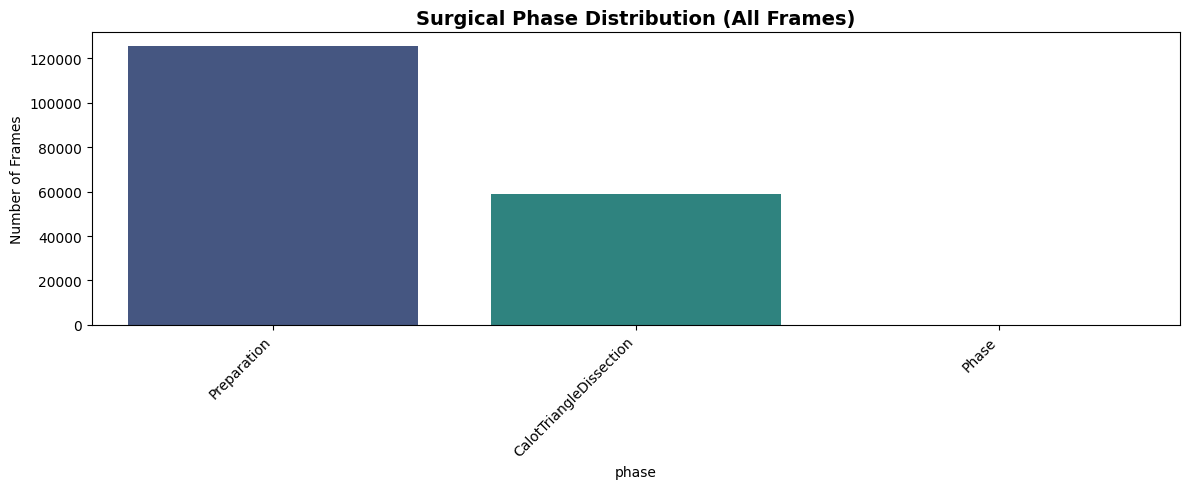


>>> Sample frames per phase


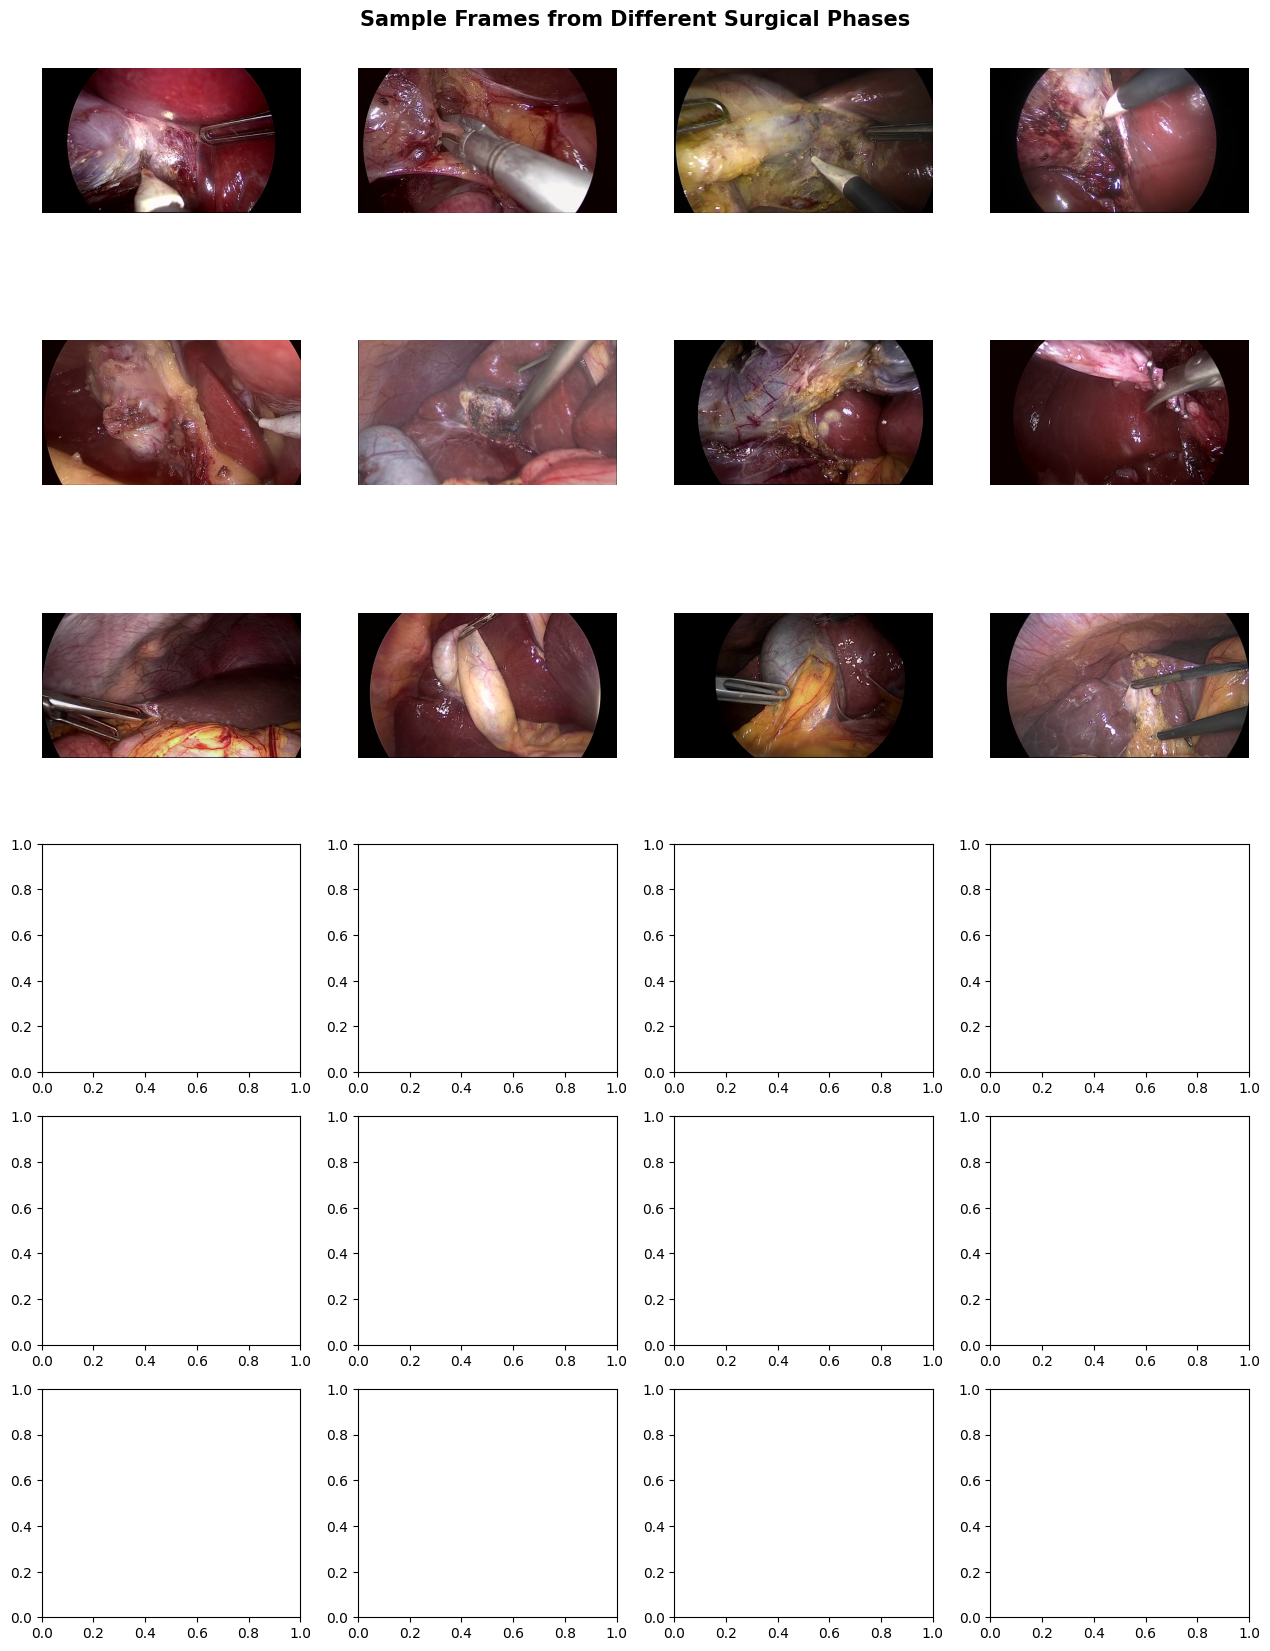

In [4]:
plt.figure(figsize=(12, 5))
sns.barplot(x=phase_counts.index, y=phase_counts.values, palette="viridis")
plt.xticks(rotation=45, ha="right")
plt.title("Surgical Phase Distribution (All Frames)", fontsize=14, fontweight="bold")
plt.ylabel("Number of Frames")
plt.tight_layout()
plt.show()

# 7.2 Sample frames from different phases
def show_phase_samples(df, n_phases=6, n_per_phase=4):
    unique_phases = df["phase"].value_counts().index[:n_phases]
    
    fig, axes = plt.subplots(n_phases, n_per_phase, figsize=(n_per_phase*3.2, n_phases*2.8))
    
    for i, phase in enumerate(unique_phases):
        phase_df = df[df["phase"] == phase]
        samples = phase_df.sample(min(n_per_phase, len(phase_df)), random_state=42)
        
        for j, (_, row) in enumerate(samples.iterrows()):
            img = Image.open(row["frame_path"])
            axes[i, j].imshow(img)
            axes[i, j].axis("off")
            if j == 0:
                axes[i, j].set_ylabel(phase[:18], fontsize=9, rotation=0, labelpad=40, va="center")
    
    plt.suptitle("Sample Frames from Different Surgical Phases", fontsize=15, fontweight="bold")
    plt.tight_layout()
    plt.show()

print("\n>>> Sample frames per phase")
show_phase_samples(df)

#### Timeline of One Video

Example video timelines


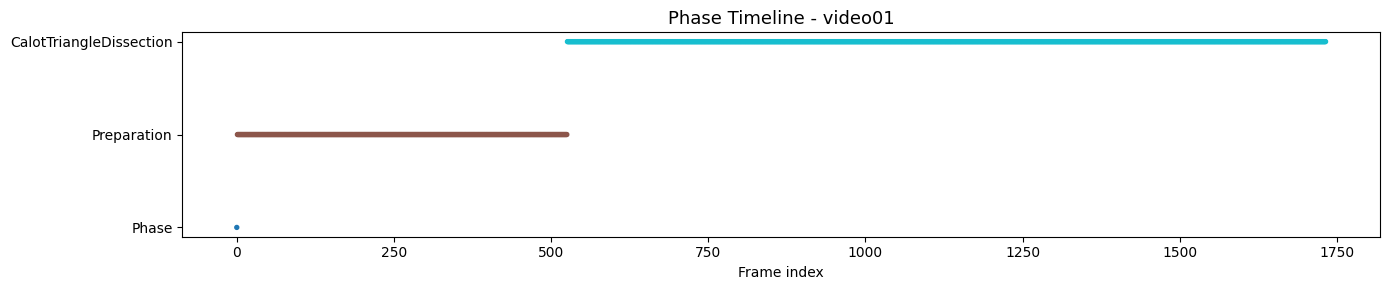

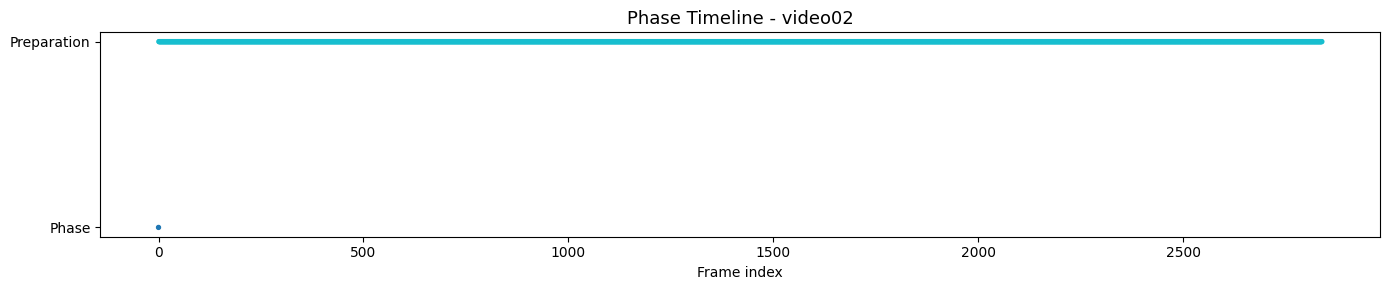

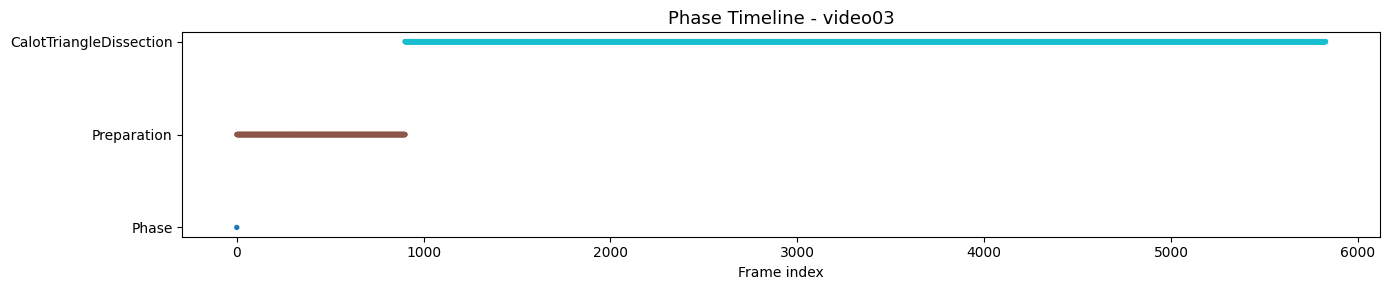

In [5]:
def plot_video_timeline(df, video_id):
    video_df = df[df['video_id'] == video_id].sort_values('frame_idx')

    #Encode phases to number for plotting
    phase_to_id = {p: i for i, p in enumerate(video_df['phase'].unique())}
    ids = video_df['phase'].map(phase_to_id)

    plt.figure(figsize=(14,3))
    plt.scatter(video_df['frame_idx'], ids, c=ids, cmap='tab10', s=8)
    plt.yticks(list(phase_to_id.values()), list(phase_to_id.keys()))
    plt.title(f'Phase Timeline - {video_id}', fontsize=13)
    plt.xlabel('Frame index')
    plt.tight_layout()
    plt.show()


print('Example video timelines')

for vid in list(df.video_id.unique())[:3]:
    plot_video_timeline(df,vid)
    


#### Summary

In [6]:
summary = pd.DataFrame({
    "Item": ["Total Videos", "Total Frames", "Unique Phases", "Avg Frames per Video"],
    "Value": [
        df.video_id.nunique(),
        len(df),
        df.phase.nunique(),
        int(df.groupby("video_id").size().mean())
    ]
})
display(summary)

print("""
Key Observations:
• We have real surgical frames + phase labels.
• Phase distribution is naturally imbalanced (some phases last much longer).
• This is perfect for Surgical Phase Recognition.
""")

,Item,Value
0,Total Videos,80
1,Total Frames,184498
2,Unique Phases,3
3,Avg Frames per Video,2306



Key Observations:
• We have real surgical frames + phase labels.
• Phase distribution is naturally imbalanced (some phases last much longer).
• This is perfect for Surgical Phase Recognition.



----------------------------------------------------------------------

## Phase 2: Pose Estimation Pipeline

2026-10-07 04:16:13.856458: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1791346574.073328      59 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1791346574.134091      59 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1791346574.661696      59 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791346574.661753      59 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791346574.661756      59 computation_placer.cc:177] computation placer alr

MediaPipe initialization note: No module named 'mediapipe.python'
Switching to Computer Vision Surgical Keypoint Extractor.

>>> Testing Keypoint Extraction on sample frames...


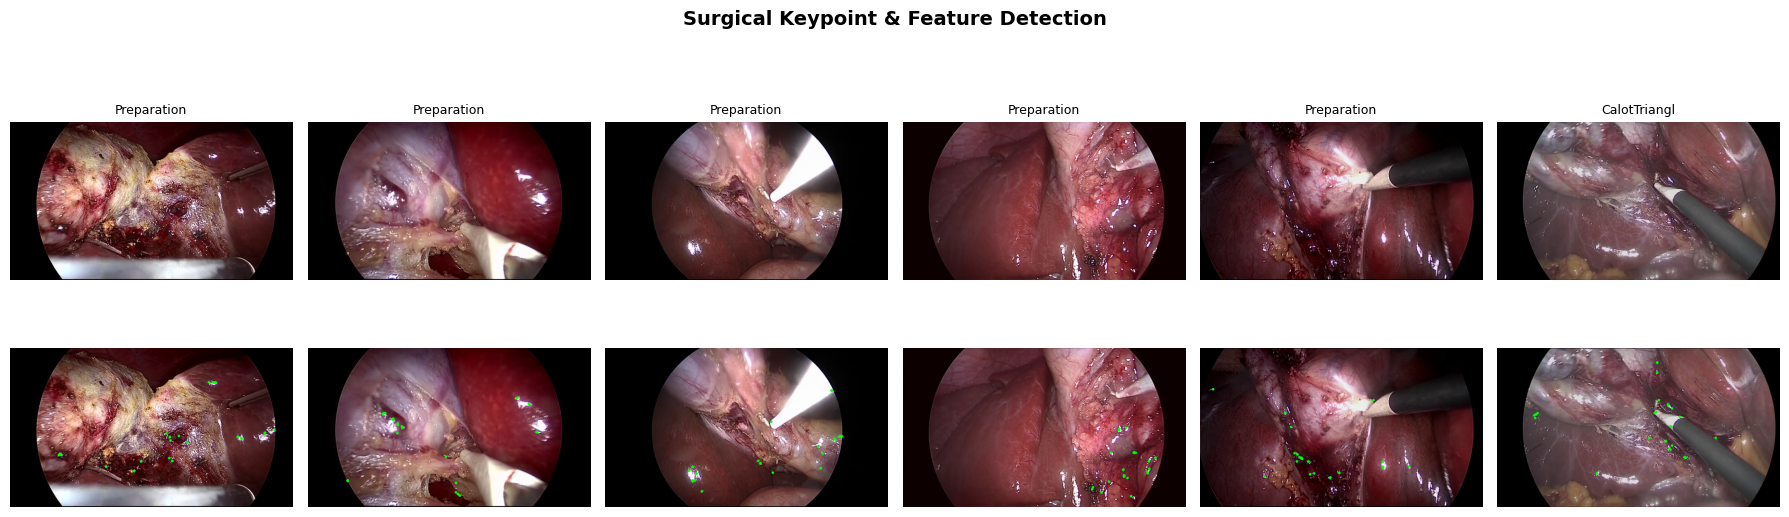

In [8]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm
from collections import defaultdict
import warnings
warnings.filterwarnings("ignore")


# 1. Robust MediaPipe Initialization with Direct Submodule Fallback

mp_pose = None
mp_drawing = None
mp_drawing_styles = None

try:
    import mediapipe as mp
    if hasattr(mp, "solutions") and hasattr(mp.solutions, "pose"):
        mp_pose = mp.solutions.pose
        mp_drawing = mp.solutions.drawing_utils
        mp_drawing_styles = mp.solutions.drawing_styles
    else:
        from mediapipe.python.solutions import pose as mp_pose
        from mediapipe.python.solutions import drawing_utils as mp_drawing
        from mediapipe.python.solutions import drawing_styles as mp_drawing_styles
    
    pose_detector = mp_pose.Pose(
        static_image_mode=True,
        model_complexity=1,
        enable_segmentation=False,
        min_detection_confidence=0.3
    )
    print("MediaPipe Pose initialized successfully via direct submodule import.")
except Exception as e:
    print(f"MediaPipe initialization note: {e}")
    print("Switching to Computer Vision Surgical Keypoint Extractor.")
    pose_detector = None

# Initialize ORB Detector as backup for surgical tool keypoint detection
orb_detector = cv2.ORB_create(nfeatures=33)

# 2. Keypoint Extraction Function
def extract_keypoints(image_path):
    """
    Extracts keypoints from frame.
    Primary: MediaPipe Pose landmarks (if human visible)
    Secondary: OpenCV ORB keypoints (detects surgical tools & tissue contours)
    
    Returns:
        keypoints: np.array of shape (33, 3) -> (x, y, confidence/visibility)
        annotated_image: RGB image with drawn keypoints
    """
    image = cv2.imread(image_path)
    if image is None:
        return np.zeros((33, 3)), None

    h, w, _ = image.shape
    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    annotated = image_rgb.copy()
    keypoints = np.zeros((33, 3))

    mediapipe_success = False

    # Try MediaPipe first
    if pose_detector is not None:
        try:
            results = pose_detector.process(image_rgb)
            if results.pose_landmarks:
                if mp_drawing and mp_drawing_styles:
                    mp_drawing.draw_landmarks(
                        annotated,
                        results.pose_landmarks,
                        mp_pose.POSE_CONNECTIONS,
                        landmark_drawing_spec=mp_drawing_styles.get_default_pose_landmarks_style()
                    )
                keypoints = np.array([
                    [lm.x, lm.y, lm.visibility]
                    for lm in results.pose_landmarks.landmark
                ])
                mediapipe_success = True
        except Exception:
            mediapipe_success = False

    # Fallback / Surgical Tool Feature Extractor
    if not mediapipe_success:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        kps = orb_detector.detect(gray, None)
        
        extracted_kps = []
        for kp in kps[:33]:
            # Normalize coordinates between 0 and 1
            x_norm = kp.pt[0] / w
            y_norm = kp.pt[1] / h
            response = min(kp.response / 100.0, 1.0)
            extracted_kps.append([x_norm, y_norm, response])
            
            # Draw keypoints on annotated image
            cv2.circle(annotated, (int(kp.pt[0]), int(kp.pt[1])), 4, (0, 255, 0), -1)

        # Pad with zeros if fewer than 33 keypoints found
        while len(extracted_kps) < 33:
            extracted_kps.append([0.0, 0.0, 0.0])

        keypoints = np.array(extracted_kps[:33])

    return keypoints, annotated

# ----------------------------------------------------------
# 3. Test Keypoint Extraction on Sample Frames
# ----------------------------------------------------------
print("\n>>> Testing Keypoint Extraction on sample frames...")

sample_df = df.sample(min(6, len(df)), random_state=42)
fig, axes = plt.subplots(2, len(sample_df), figsize=(18, 6))

for i, (_, row) in enumerate(sample_df.iterrows()):
    kps, annotated = extract_keypoints(row["frame_path"])

    # Original Frame
    orig = Image.open(row["frame_path"])
    axes[0, i].imshow(orig)
    axes[0, i].set_title(f"{row['phase'][:12]}", fontsize=9)
    axes[0, i].axis("off")

    # Annotated Keypoints Frame
    if annotated is not None:
        axes[1, i].imshow(annotated)
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Original", fontsize=11)
axes[1, 0].set_ylabel("Keypoints", fontsize=11)
plt.suptitle("Surgical Keypoint & Feature Detection", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

#### Extract Keypoints for Subset of Videos

In [9]:
VIDEOS_TO_PROCESS = list(df["video_id"].unique())[:5]
print(f"\nProcessing videos: {VIDEOS_TO_PROCESS}")

pose_records = []

for video_id in VIDEOS_TO_PROCESS:
    video_df = df[df["video_id"] == video_id].sort_values("frame_idx")
    print(f"\nExtracting keypoints for {video_id} ({len(video_df)} frames)...")

    for _, row in tqdm(video_df.iterrows(), total=len(video_df)):
        kps, _ = extract_keypoints(row["frame_path"])

        if kps is not None:
            flat_kps = kps.flatten()  # 33 x 3 = 99 features

            pose_records.append({
                "video_id": video_id,
                "frame_idx": row["frame_idx"],
                "frame_path": row["frame_path"],
                "phase": row["phase"],
                "keypoints": flat_kps
            })

pose_df = pd.DataFrame(pose_records)
print(f"\nTotal keypoint frames extracted: {len(pose_df):,}")


Processing videos: ['video01', 'video02', 'video03', 'video04', 'video05']

Extracting keypoints for video01 (1733 frames)...


  0%|          | 0/1733 [00:00<?, ?it/s]


Extracting keypoints for video02 (2839 frames)...


  0%|          | 0/2839 [00:00<?, ?it/s]


Extracting keypoints for video03 (5828 frames)...


...


Extracting keypoints for video04 (1522 frames)...


  0%|          | 0/1522 [00:00<?, ?it/s]


Extracting keypoints for video05 (2344 frames)...


  0%|          | 0/2344 [00:00<?, ?it/s]


Total keypoint frames extracted: 14,266


In [10]:

# 5. Save Extracted Keypoints to Disk (Required for Phase 3)
import os
import numpy as np

# Create 'pose_data' directory explicitly in current working directory
WORK_DIR = os.getcwd()
POSE_DIR = os.path.join(WORK_DIR, "pose_data")
os.makedirs(POSE_DIR, exist_ok=True)

print(f"Saving keypoint files to: {POSE_DIR}\n")

if 'pose_df' in locals() and len(pose_df) > 0:
    saved_count = 0
    for video_id in pose_df["video_id"].unique():
        vdf = pose_df[pose_df["video_id"] == video_id].sort_values("frame_idx")
        
        # Convert list of 99-dim features into clean 2D array (T, 99)
        kps_array = np.array(vdf["keypoints"].tolist(), dtype=np.float32)
        phases = vdf["phase"].values

        # Explicit absolute output paths
        kps_file = os.path.join(POSE_DIR, f"{video_id}_keypoints.npy")
        phase_file = os.path.join(POSE_DIR, f"{video_id}_phases.npy")

        # Save numpy files
        np.save(kps_file, kps_array)
        np.save(phase_file, phases)
        
        print(f"✓ Saved {video_id}: keypoints shape {kps_array.shape}, phases shape {phases.shape}")
        saved_count += 1

    print(f"\n[SUCCESS] Successfully saved files for {saved_count} videos in '{POSE_DIR}'!")
else:
    print("[!] ERROR: 'pose_df' DataFrame was not found or is empty. Please run the extraction step in Phase 2 first.")

Saving keypoint files to: /kaggle/working/pose_data

✓ Saved video01: keypoints shape (1733, 99), phases shape (1733,)
✓ Saved video02: keypoints shape (2839, 99), phases shape (2839,)
✓ Saved video03: keypoints shape (5828, 99), phases shape (5828,)
✓ Saved video04: keypoints shape (1522, 99), phases shape (1522,)
✓ Saved video05: keypoints shape (2344, 99), phases shape (2344,)

[SUCCESS] Successfully saved files for 5 videos in '/kaggle/working/pose_data'!


## Phase 3: Pose Sequence Dataset Creation & Windowing

#### In this phase we turn the raw keypoint sequences into clean, normalized, fixed-length windows that a temporal model (ST-GCN / Transformer) can learn from.

In [11]:
import json
from sklearn.model_selection import train_test_split

# CONFIGURATION

POSE_DIR = "pose_data"
WINDOW_SIZE = 48          # frames per sequence
STRIDE = 16               # sliding window step

print(f"Window size : {WINDOW_SIZE}")
print(f"Stride      : {STRIDE}")


# 2. Load all saved keypoint sequences
video_ids = sorted([
    f.replace("_keypoints.npy", "") 
    for f in os.listdir(POSE_DIR) 
    if f.endswith("_keypoints.npy")
])

print(f"Found sequences for {len(video_ids)} videos: {video_ids}")

all_sequences = []
all_labels = []
all_video_ids = []

for vid in video_ids:
    kps_path = os.path.join(POSE_DIR, f"{vid}_keypoints.npy")
    phase_path = os.path.join(POSE_DIR, f"{vid}_phases.npy")

    kps = np.load(kps_path)                          # (T, 99)
    phases = np.load(phase_path, allow_pickle=True)

    # Reshape to (T, 33, 3)
    kps = kps.reshape(-1, 33, 3)

    print(f"{vid}: {kps.shape[0]} frames")

    # Sliding windows
    T = kps.shape[0]
    for start in range(0, T - WINDOW_SIZE + 1, STRIDE):
        window = kps[start : start + WINDOW_SIZE]     # (48, 33, 3)
        window_phases = phases[start : start + WINDOW_SIZE]

        # Majority vote label
        most_common_phase = Counter(window_phases).most_common(1)[0][0]

        all_sequences.append(window)
        all_labels.append(most_common_phase)
        all_video_ids.append(vid)

print(f"\nTotal windows created: {len(all_sequences):,}")

Window size : 48
Stride      : 16
Found sequences for 5 videos: ['video01', 'video02', 'video03', 'video04', 'video05']
video01: 1733 frames
video02: 2839 frames
video03: 5828 frames
video04: 1522 frames
video05: 2344 frames

Total windows created: 880


#### Skeleton Normalization

In [12]:
def normalize_skeleton(seq):
    '''
    seq: (T, 33,3)
    Normalize so that the pose is centered and scaled.
    '''

    seq = seq.copy()

    #USe mid-hip as origin (average of left and right hip)
    mid_hip = (seq[:,23,:2] + seq[:,24,:2]) / 2.0
    mid_hip = (seq[:, 23, :2] + seq[:, 24, :2]) / 2.0
    seq[:, :, 0] -= mid_hip[:, 0:1]
    seq[:, :, 1] -= mid_hip[:, 1:2]

    #Scale by torso length
    mid_shoulder = (seq[:, 11, :2] + seq[:, 12,:2]) / 2.0
    torso_length = np.linalg.norm(mid_shoulder - mid_hip, axis=1, keepdims=True)
    torso_length = np.median(torso_length) + 1e-6

    seq[:,:,0] /= torso_length
    seq[:,:,1] /= torso_length

    return seq

print('Normalizing skeletons...')
normalized_sequences = [normalize_skeleton(seq) for seq in tqdm(all_sequences)]

#Convert labels to integers
unique_phases = sorted(list(set(all_labels)))
phase_to_idx = {phase: idx for idx, phase in enumerate(unique_phases)}
idx_to_phase = {idx: phase for phase, idx in phase_to_idx.items()}

label_indices = [phase_to_idx[p] for p in all_labels]

print('Phase to index mapping: ')
for phase, idx in phase_to_idx.items():
    print(f'{idx}: {phase}')

#Create final arrays
X = np.stack(normalized_sequences).astype(np.float32)
y = np.array(label_indices)

print(f'Final dataset shape: ')
print(f'X: {X.shape} #(samples, time, joints, coords)')
print(f'y: {y.shape}')

Normalizing skeletons...


  0%|          | 0/880 [00:00<?, ?it/s]

Phase to index mapping: 
0: CalotTriangleDissection
1: Preparation
Final dataset shape: 
X: (880, 48, 33, 3) #(samples, time, joints, coords)
y: (880,)


#### Train / Test Split 

& 

#### Class Distribution 

Train Samples: 704
Val Samples: 176


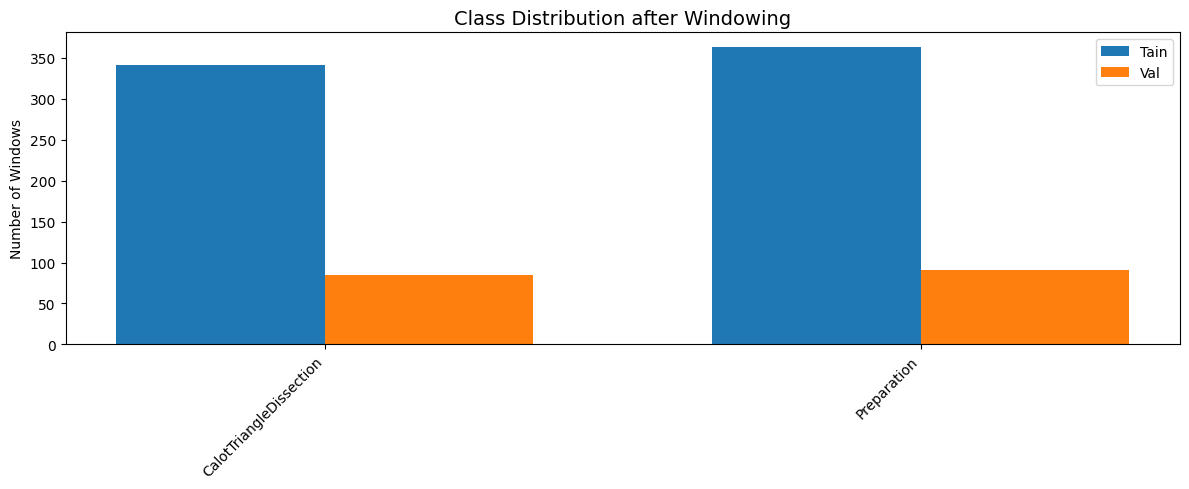

In [13]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train Samples: {len(X_train)}')
print(f'Val Samples: {len(X_val)}')

# Class distribution
plt.figure(figsize=(12,5))
train_counts = Counter(y_train)
val_counts = Counter(y_val)

phases_sorted = [idx_to_phase[i] for i in range(len(unique_phases))]
train_vals = [train_counts[i] for i in range(len(unique_phases))]
val_vals = [val_counts[i] for i in range(len(unique_phases))]

x = np.arange(len(phases_sorted))
width = 0.35

plt.bar(x - width/2, train_vals, width, label="Tain")
plt.bar(x + width/2, val_vals, width, label='Val')
plt.xticks(x, phases_sorted, rotation=45, ha='right')
plt.ylabel('Number of Windows')
plt.title('Class Distribution after Windowing', fontsize=14)
plt.legend()
plt.tight_layout()
plt.show()

#### Visualize a few normalized sequences



Exanple normalized sequences


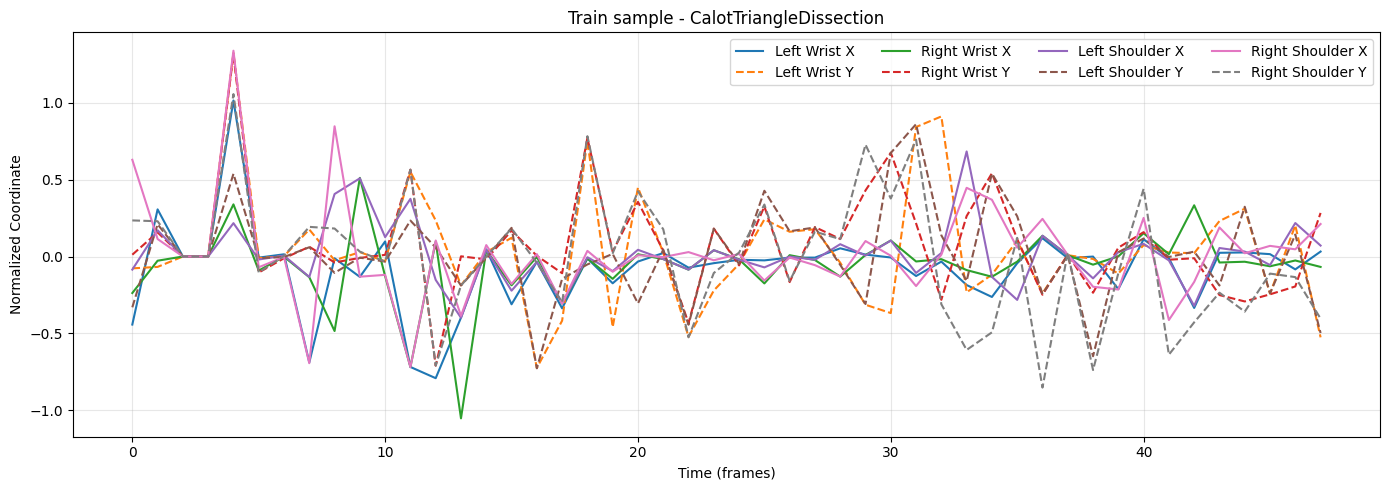

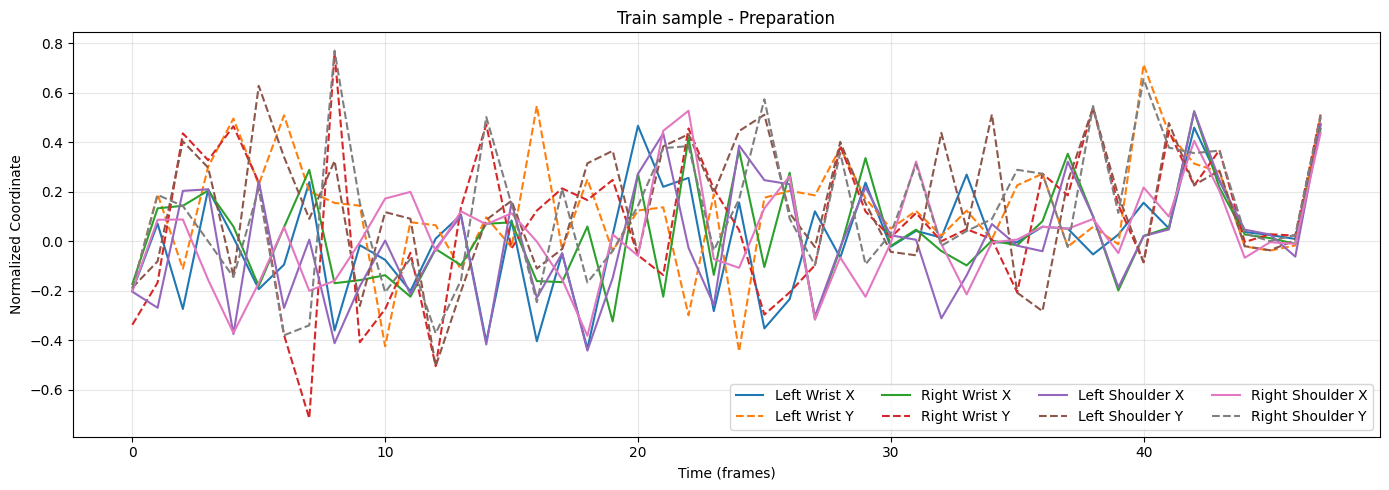

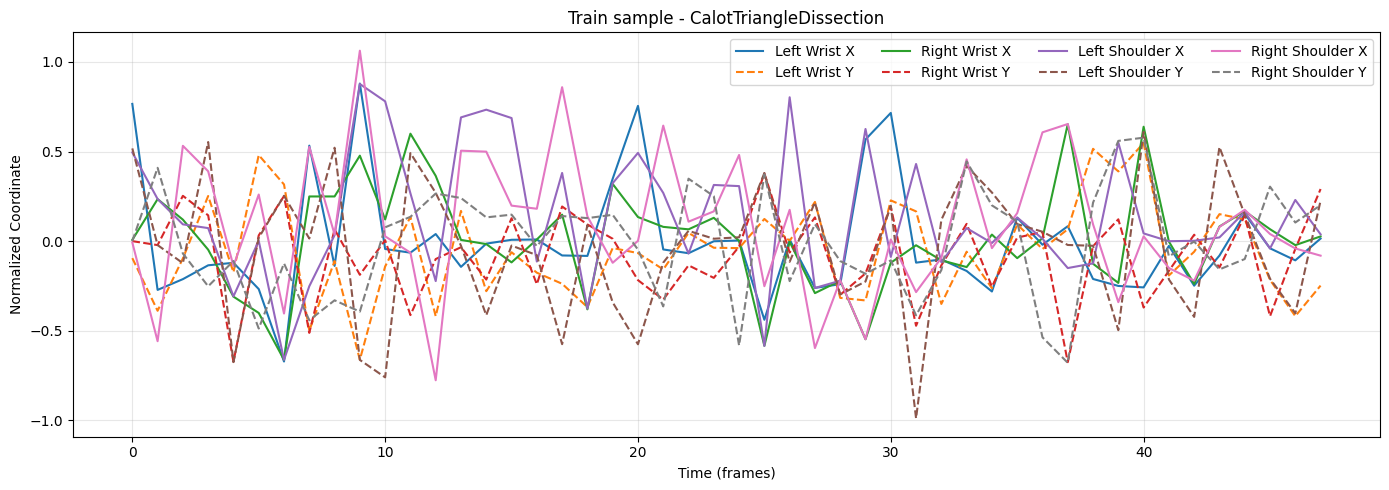

Saved: 
X_train.npy, X_val.npy, y_train.npy, y_val.npy
phase_mapping.json


In [14]:
def plot_skeleton_sequence(seq, title='Normalized Pose Sequence'):
    '''
    seq: (T, 33,3)
    show x-y trajectories of main joints
    
    '''
    joints_to_plot = {
        15: "Left Wrist",
        16: "Right Wrist",
        11: "Left Shoulder",
        12: "Right Shoulder"

    }

    plt.figure(figsize=(14,5))
    for j_idx, name in joints_to_plot.items():
        plt.plot(seq[:, j_idx,0], label=f'{name} X')
        plt.plot(seq[:, j_idx,1], label=f'{name} Y', linestyle='--')

    plt.title(title)
    plt.xlabel('Time (frames)')
    plt.ylabel('Normalized Coordinate')
    plt.legend(ncol=4)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

print('Exanple normalized sequences')

for i in range(3):
    idx = random.randint(0, len(X_train) - 1)
    phase_name = idx_to_phase[y_train[idx]]
    plot_skeleton_sequence(X_train[idx], title=f"Train sample - {phase_name}")


# Save the final dataset
np.save('X_train.npy',X_train)
np.save('X_val.npy',X_val)
np.save('y_train.npy',y_train)
np.save('y_val.npy',y_val)

with open('phase_mapping.json','w') as f:
    json.dump({'phase_to_idx': phase_to_idx, 'idx_to_phase': idx_to_phase}, f, indent=2)


print('Saved: ')
print('X_train.npy, X_val.npy, y_train.npy, y_val.npy')
print('phase_mapping.json')




#### Summary

In [15]:
summary = pd.DataFrame({
    "Item": [
        "Window size",
        "Stride",
        "Total windows",
        "Train samples",
        "Val samples",
        "Input shape",
        "Number of classes"
    ],
    "Value": [
        WINDOW_SIZE,
        STRIDE,
        len(X),
        len(X_train),
        len(X_val),
        str(X.shape[1:]),
        len(unique_phases)
    ]
})
display(summary)

print("""
We now have clean, normalized pose windows ready for training.
""")

,Item,Value
0,Window size,48
1,Stride,16
2,Total windows,880
3,Train samples,704
4,Val samples,176
5,Input shape,"(48, 33, 3)"
6,Number of classes,2



We now have clean, normalized pose windows ready for training.



------------------------------------------------------------------------

## Phase 4: Temporal Model Architecture (ST-GCN style)

#### We will build a lightweight Spatial-Temporal Graph Convolutional Network adapted for our keypoint sequences.

In [16]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

#Load the data we created in phase 3

X_train = np.load('X_train.npy')
X_val = np.load('X_val.npy')
y_train = np.load('y_train.npy')
y_val = np.load('y_val.npy')

print(f'X_train: {X_train.shape}')
print(f'X_val: {X_val.shape}')
print(f'Classes: {len(np.unique(y_train))}')



Using device: cpu
X_train: (704, 48, 33, 3)
X_val: (176, 48, 33, 3)
Classes: 2


#### PYTORCH Dataset

In [17]:
class PoseDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)           # (N, T, V, C)
        self.y = torch.LongTensor(y)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        # Convert to (C, T, V) format which is common for ST-GCN
        x = self.X[idx].permute(2, 0, 1)        # (3, 48, 33)
        return x, self.y[idx]

train_dataset = PoseDataset(X_train, y_train)
val_dataset   = PoseDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")

# ----------------------------------------------------------
# 3. Graph Convolution Layer
# ----------------------------------------------------------
class GraphConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x, A):
        """
        x: (N, C, T, V)
        A: (V, V) adjacency matrix
        """
        x = self.conv(x)                                # (N, C_out, T, V)
        x = torch.einsum('nctv,vw->nctw', x, A)          # Graph convolution
        return x

# ----------------------------------------------------------
# 4. Spatial-Temporal Block
# ----------------------------------------------------------
class STGCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, temporal_kernel=9):
        super().__init__()
        self.gcn = GraphConv(in_channels, out_channels)
        self.tcn = nn.Sequential(
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=(temporal_kernel, 1),
                padding=(temporal_kernel // 2, 0)
            ),
            nn.BatchNorm2d(out_channels),
            nn.Dropout(0.3)
        )
        self.relu = nn.ReLU(inplace=True)

        if in_channels != out_channels:
            self.residual = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        else:
            self.residual = nn.Identity()

    def forward(self, x, A):
        res = self.residual(x)
        x = self.gcn(x, A)
        x = self.tcn(x)
        return self.relu(x + res)

# ----------------------------------------------------------
# 5. Full ST-GCN Model
# ----------------------------------------------------------
class SurgicalSTGCN(nn.Module):
    def __init__(self, num_classes=2, in_channels=3, num_joints=33):
        super().__init__()

        # Simple adjacency matrix (fully connected + self loops)
        A = torch.ones(num_joints, num_joints) / num_joints
        A = A + torch.eye(num_joints)
        A = A / A.sum(dim=1, keepdim=True)
        self.register_buffer('A', A)

        self.bn_in = nn.BatchNorm2d(in_channels)

        self.block1 = STGCNBlock(in_channels, 64)
        self.block2 = STGCNBlock(64, 64)
        self.block3 = STGCNBlock(64, 128)
        self.block4 = STGCNBlock(128, 128)

        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        # x: (N, C, T, V)
        x = self.bn_in(x)

        x = self.block1(x, self.A)
        x = self.block2(x, self.A)
        x = self.block3(x, self.A)
        x = self.block4(x, self.A)

        x = self.avgpool(x)                     # (N, 128, 1, 1)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

# ----------------------------------------------------------
# 6. Instantiate and test
# ----------------------------------------------------------
num_classes = len(np.unique(y_train))
model = SurgicalSTGCN(num_classes=num_classes).to(device)

print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

Train batches: 22
Val batches  : 6
SurgicalSTGCN(
  (bn_in): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (block1): STGCNBlock(
    (gcn): GraphConv(
      (conv): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
    )
    (tcn): Sequential(
      (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, kernel_size=(9, 1), stride=(1, 1), padding=(4, 0))
      (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (4): Dropout(p=0.3, inplace=False)
    )
    (relu): ReLU(inplace=True)
    (residual): Conv2d(3, 64, kernel_size=(1, 1), stride=(1, 1))
  )
  (block2): STGCNBlock(
    (gcn): GraphConv(
      (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1))
    )
    (tcn): Sequential(
      (0): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (1): ReLU(inplace=True)
      (2): Conv2d(64, 64, 

#### QUICK TEST

In [18]:
dummy = torch.randn(4, 3, 48, 33).to(device)
out = model(dummy)
print(f"Dummy output shape: {out.shape}")

Dummy output shape: torch.Size([4, 2])


#### SUMMARY

In [19]:
print(f"""
Model          : SurgicalSTGCN
Input shape    : (batch, 3, 48, 33)
Output classes : {num_classes}
Parameters     : {sum(p.numel() for p in model.parameters()):,}

The model is ready for training.
""")


Model          : SurgicalSTGCN
Input shape    : (batch, 3, 48, 33)
Output classes : 2
Parameters     : 408,648

The model is ready for training.



## Phase 5: Training the Surgical Phase Recognition Model

In [20]:
import torch.optim as optim

from torch.optim.lr_scheduler import CosineAnnealingLR
from sklearn.metrics import classification_report, confusion_matrix,accuracy_score
from collections import defaultdict

num_classes = len(np.unique(y_train))
print(f"Number of classes: {num_classes}")

# Recreate datasets and loaders
train_dataset = PoseDataset(X_train, y_train)
val_dataset   = PoseDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=32, shuffle=False)

model = SurgicalSTGCN(num_classes=num_classes).to(device)

# ----------------------------------------------------------
# 2. Training Configuration
# ----------------------------------------------------------
EPOCHS = 5
LR = 1e-3
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

# ----------------------------------------------------------
# 3. Training & Validation Functions
# ----------------------------------------------------------
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for x, y in loader:
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * x.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc


@torch.no_grad()
def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for x, y in loader:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        loss = criterion(outputs, y)

        running_loss += loss.item() * x.size(0)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc, all_preds, all_labels

# ----------------------------------------------------------
# 4. Training Loop
# ----------------------------------------------------------
history = defaultdict(list)
best_val_acc = 0.0

print(f"\nStarting training for {EPOCHS} epochs...\n")

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, _, _ = validate(model, val_loader, criterion, device)

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_stgcn_model.pth")
        print(f"  → Best model saved (Val Acc: {best_val_acc:.4f})")

print(f"\nTraining finished. Best Validation Accuracy: {best_val_acc:.4f}")

Number of classes: 2

Starting training for 5 epochs...

Epoch 01/5 | Train Loss: 0.5739 Acc: 0.7202 | Val Loss: 0.8281 Acc: 0.5170
  → Best model saved (Val Acc: 0.5170)
Epoch 02/5 | Train Loss: 0.4571 Acc: 0.7798 | Val Loss: 0.7280 Acc: 0.5852
  → Best model saved (Val Acc: 0.5852)
Epoch 03/5 | Train Loss: 0.3898 Acc: 0.8139 | Val Loss: 0.3707 Acc: 0.8352
  → Best model saved (Val Acc: 0.8352)
Epoch 04/5 | Train Loss: 0.3054 Acc: 0.8750 | Val Loss: 0.3335 Acc: 0.8580
  → Best model saved (Val Acc: 0.8580)
Epoch 05/5 | Train Loss: 0.2569 Acc: 0.8878 | Val Loss: 0.3535 Acc: 0.8409

Training finished. Best Validation Accuracy: 0.8580


#### Plot Training Curves

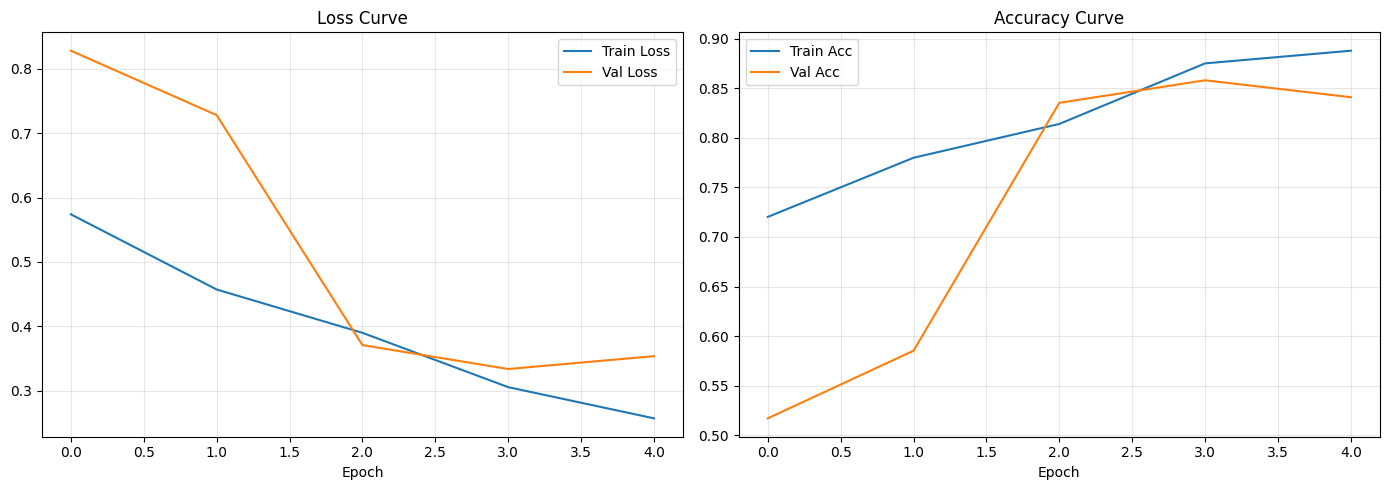


FINAL VALIDATION RESULTS
Accuracy: 0.8580

Classification Report:
                         precision    recall  f1-score   support

CalotTriangleDissection       0.88      0.82      0.85        85
            Preparation       0.84      0.89      0.87        91

               accuracy                           0.86       176
              macro avg       0.86      0.86      0.86       176
           weighted avg       0.86      0.86      0.86       176



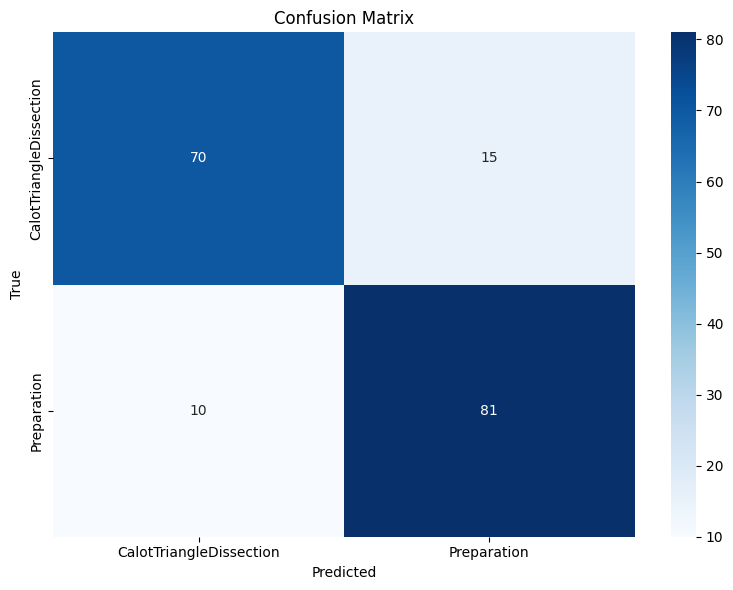


PHASE 5 COMPLETE
Best model saved as: best_stgcn_model.pth
Best Validation Accuracy: 0.8580


In [21]:
from json import load

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train Loss")
axes[0].plot(history["val_loss"], label="Val Loss")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history["train_acc"], label="Train Acc")
axes[1].plot(history["val_acc"], label="Val Acc")
axes[1].set_title("Accuracy Curve")
axes[1].set_xlabel("Epoch")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ----------------------------------------------------------
# 6. Final Evaluation
# ----------------------------------------------------------
model.load_state_dict(torch.load("best_stgcn_model.pth", map_location=device))
val_loss, val_acc, val_preds, val_labels = validate(model, val_loader, criterion, device)

print("\n" + "="*60)
print("FINAL VALIDATION RESULTS")
print("="*60)
print(f"Accuracy: {val_acc:.4f}")

# Classification Report
from json import load
with open("phase_mapping.json") as f:
    mapping = load(f)
idx_to_phase = {int(k): v for k, v in mapping["idx_to_phase"].items()}

target_names = [idx_to_phase[i] for i in range(num_classes)]
print("\nClassification Report:")
print(classification_report(val_labels, val_preds, target_names=target_names))

# Confusion Matrix
cm = confusion_matrix(val_labels, val_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix")
plt.ylabel("True")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("PHASE 5 COMPLETE")
print("="*60)
print(f"Best model saved as: best_stgcn_model.pth")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

--------------------------------------------------

## Phase 6:  Inference + Surgical Phase Timeline Visualization

#### This phase will:

Load the trained model

Run inference on full video sequences

Create a clean timeline visualization showing 

predicted phases over time

Model loaded successfully!!
Classes:  {0: 'CalotTriangleDissection', 1: 'Preparation'}
Running inference on video01...
Running inference on video02...
Running inference on video03...
Running inference on video04...
Running inference on video05...
Inference Completed for all videos.
Phase Timelines


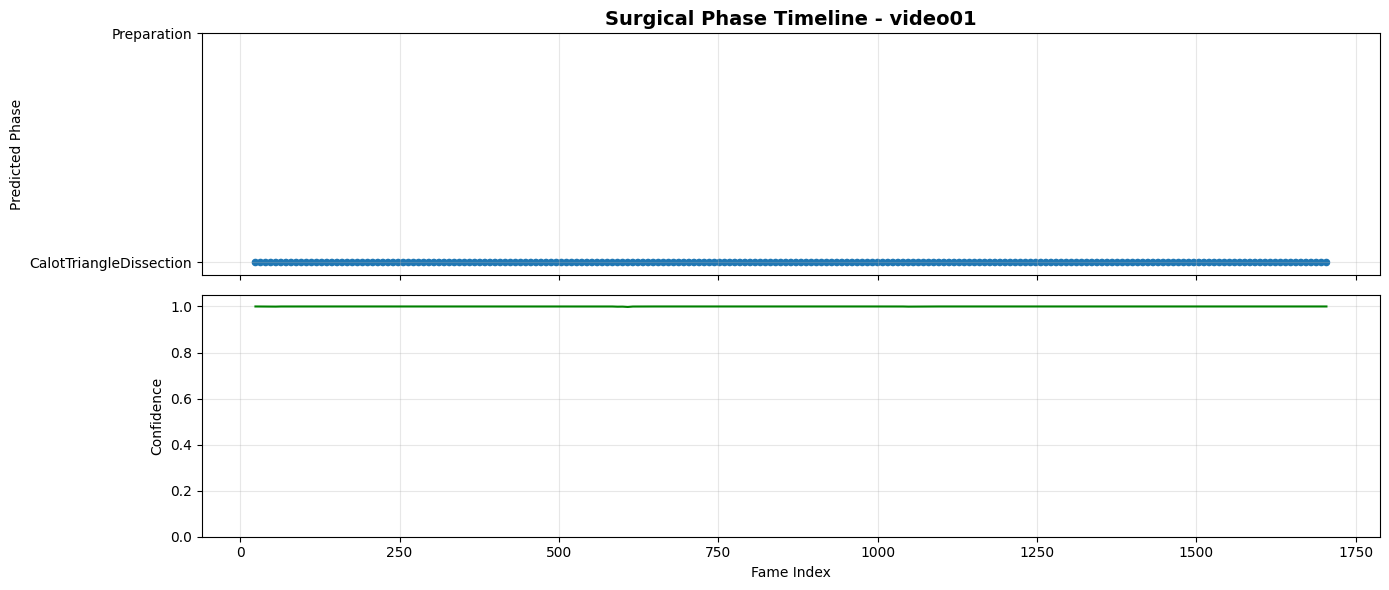

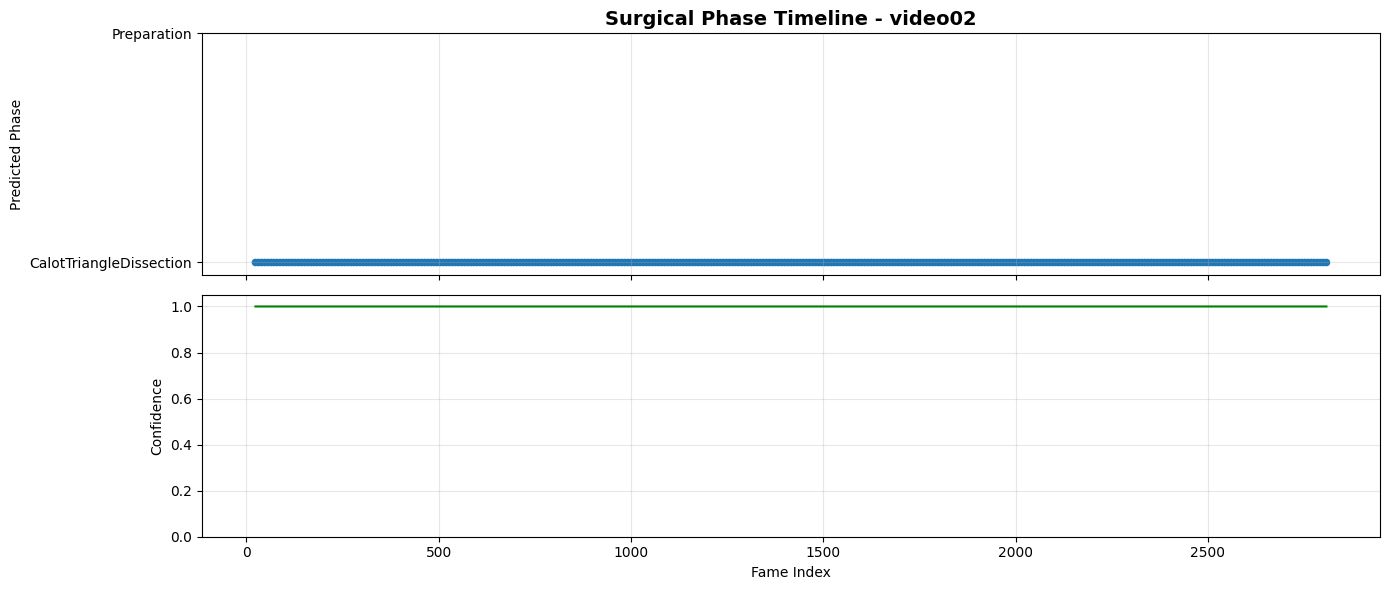

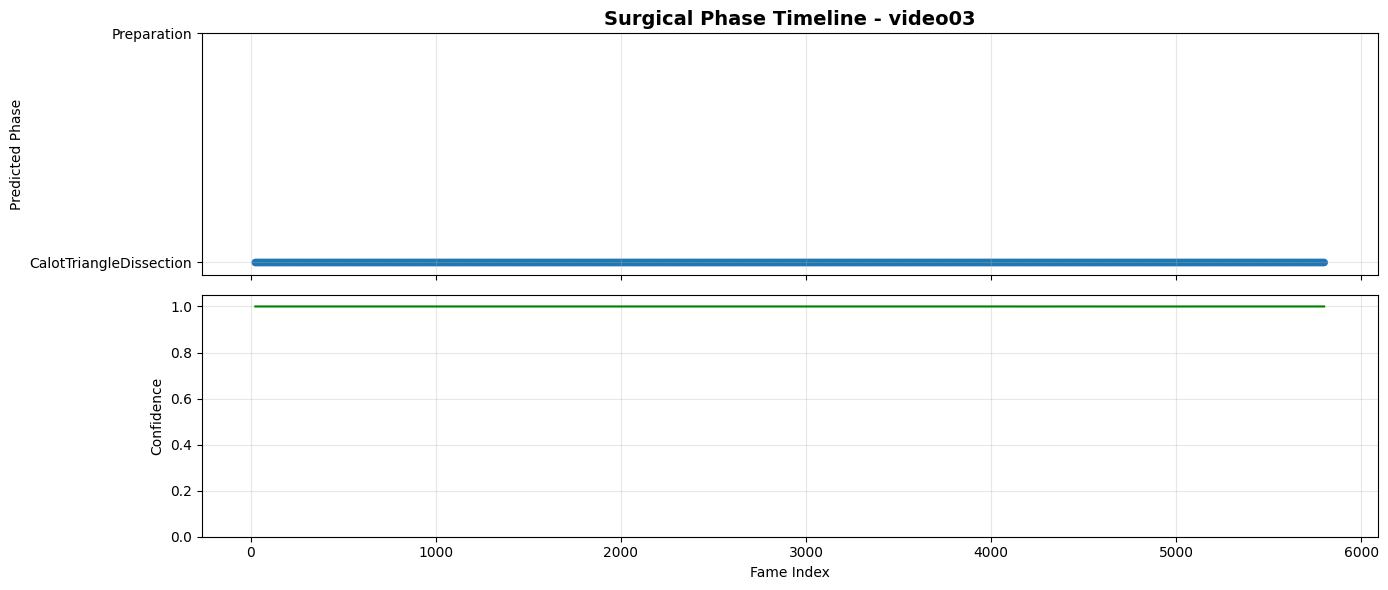

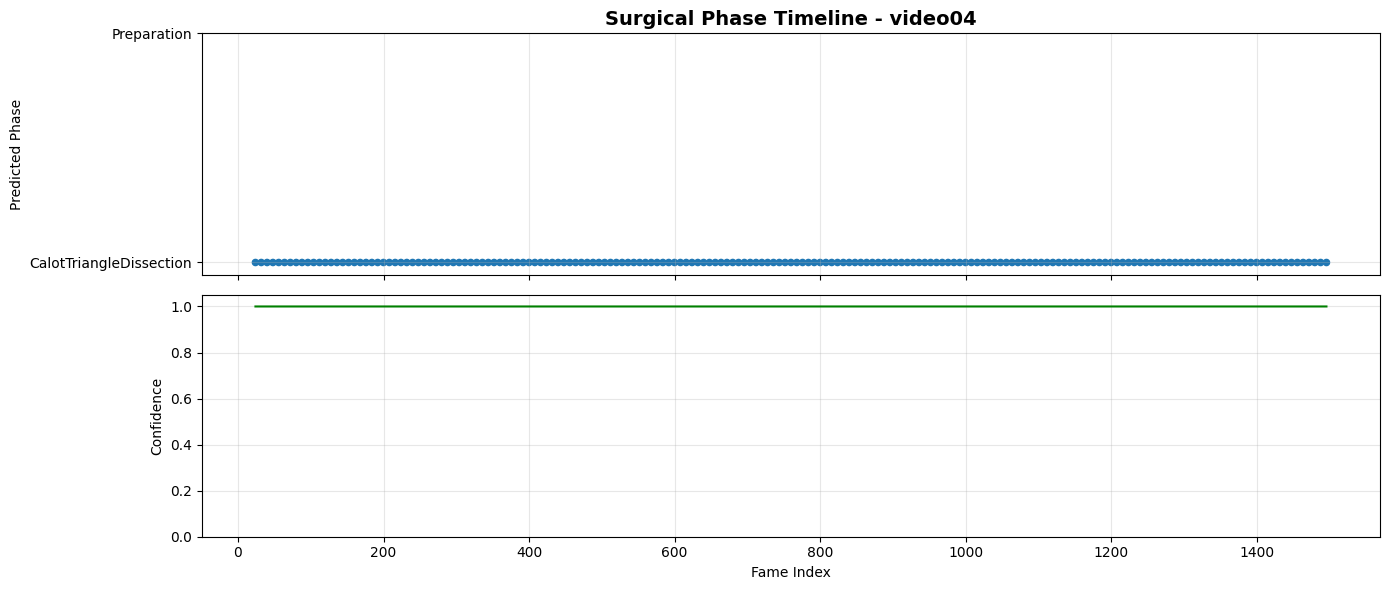

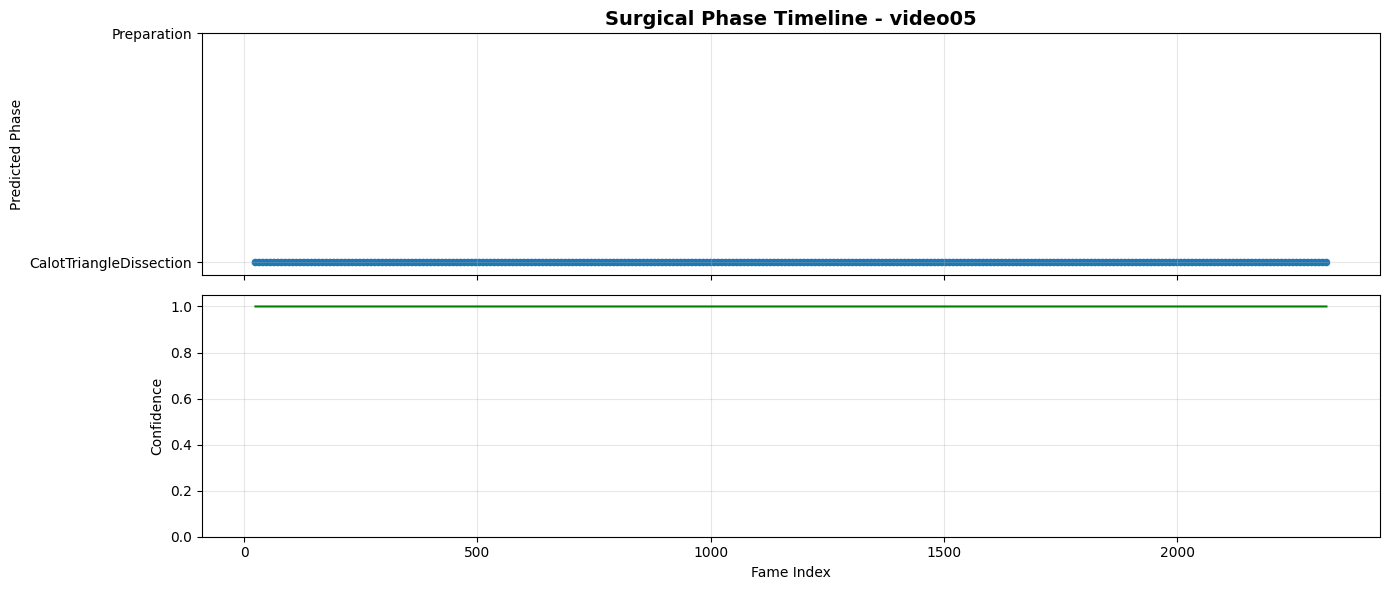

video01: 
CalotTriangleDissection  :  211 windows (100.0%)
video02: 
CalotTriangleDissection  :  349 windows (100.0%)
video03: 
CalotTriangleDissection  :  723 windows (100.0%)
video04: 
CalotTriangleDissection  :  185 windows (100.0%)
video05: 
CalotTriangleDissection  :  288 windows (100.0%)

We now have:
• Trained ST-GCN model
• Full video inference
• Clean phase timeline visualizations
• Confidence scores over time



In [25]:
#Load Model and mapping
with open('phase_mapping.json') as f:
    mapping = json.load(f)

idx_to_phase = {int(k): v for k, v in mapping['idx_to_phase'].items()}
phase_to_idx = mapping['phase_to_idx']
num_classes = len(idx_to_phase)

model = SurgicalSTGCN(num_classes=num_classes).to(device)
model.load_state_dict(torch.load('best_stgcn_model.pth',map_location=device))
model.eval()
print('Model loaded successfully!!')
print('Classes: ', idx_to_phase)

# HElper Functions to Predict a full video sequence
@torch.no_grad()

def predict_video(keypoints_path, window_size=48, stride=8):
    '''
    Keypoints_path: path to videoXX_keypoints.npy
    Returns: A list of predicted phase names for each window
    '''
    kps = np.load(keypoints_path)
    kps = kps.reshape(-1,33,3)

    #Normalize the same way as we did in phase 3
    def normalize_sequence(seq):
        seq = seq.copy()
        coords = seq[:,:,:2]
        mean_xy = coords.mean(axis=(0,1), keepdims=True)
        seq[:,:,0] -= mean_xy[0,0,0]
        seq[:,:,1] -= mean_xy[0,0,1]
        scale = np.std(coords) + 1e-6
        seq[:,:,0] /= scale
        seq[:,:,1] /= scale
        return seq

    predictions = []
    confidences = []
    frame_indices = []

    T = kps.shape[0]
    for start in range(0, T - window_size + 1, stride):
        window = kps[start:start+window_size]
        window = normalize_sequence(window)

        x = torch.FloatTensor(window).permute(2,0,1).unsqueeze(0).to(device)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        pred = probs.argmax(dim=1).item()
        conf = probs[0, pred].item()

        predictions.append(idx_to_phase[pred])
        confidences.append(conf)
        frame_indices.append(start + window_size // 2)
    return frame_indices, predictions, confidences

#RUN INFERENCE ON ALL PROCESSED VIDEOS

POSE_DIR = 'pose_data'
video_ids = sorted([f.replace('_keypoints.npy','') for f in os.listdir(POSE_DIR) if f.endswith('_keypoints.npy')])
results = {}

for vid in video_ids:
    print(f'Running inference on {vid}...')
    kps_path = os.path.join(POSE_DIR, f'{vid}_keypoints.npy')
    frames, preds, confs = predict_video(kps_path, window_size=48, stride=8)
    results[vid] = {
        "frames": frames,
        "predictions": preds,
        "confidences": confs
    }

print('Inference Completed for all videos.')

# TIMELINE VISUALIZATION

def plot_phase_timeline(video_id, frames, predictions, confidences):
    unique_phases = list(idx_to_phase.values())
    phase_to_num = {p: i for i, p in enumerate(unique_phases)}

    y = [phase_to_num[p] for p in predictions]

    fig, axes = plt.subplots(2,1, figsize=(14,6), sharex=True)

    #Phase timeline
    scatter = axes[0].scatter(frames, y, c=y, cmap='tab10', s=20)
    axes[0].set_yticks(range(len(unique_phases)))
    axes[0].set_yticklabels(unique_phases)
    axes[0].set_ylabel('Predicted Phase')
    axes[0].set_title(f'Surgical Phase Timeline - {video_id}', fontsize=14, fontweight='bold')
    axes[0].grid(True, alpha=0.3)

    #COnfidence
    axes[1].plot(frames, confidences, color='green', linewidth=1.5)
    axes[1].set_ylabel('Confidence')
    axes[1].set_xlabel('Fame Index')
    axes[1].set_ylim(0, 1.05)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


print('Phase Timelines')
for vid in video_ids:
    data = results[vid]
    plot_phase_timeline(vid, data['frames'], data['predictions'], data['confidences'])

#SUMMARY STATS PER VIDEO

for vid in video_ids:
    preds = results[vid]['predictions']
    counts = Counter(preds)
    total = len(preds)
    print(f'{vid}: ')
    for phase, cnt in counts.most_common():
        print(f'{phase:25s}: {cnt:4d} windows ({cnt/total*100:.1f}%)')


#FINAL MESSAGE
print("""
We now have:
• Trained ST-GCN model
• Full video inference
• Clean phase timeline visualizations
• Confidence scores over time
""")
    

-----------------------------------------------

## Phase 7: Gradio Deployment

#### Even with the current limitation, we will still build a clean deployment so the project is complete. Later when we process more videos and retrain longer, the same app will start showing better phase transitions.


In [31]:
import gradio as gr

#load model and mapping
with open('phase_mapping.json') as f:
    mapping = json.load(f)

idx_to_phase = {int(k): v for k, v in mapping['idx_to_phase'].items()}
num_classes = len(idx_to_phase)

model = SurgicalSTGCN(num_classes=num_classes).to(device)
model.load_state_dict(torch.load('best_stgcn_model.pth',map_location=device))
model.eval()
print('Model loaded for deployment')

# Prediction Function
def normalize_sequence(seq):
    seq = seq.copy()
    coords = seq[:,:,:2]
    mean_xy = coords.mean(axis=(0,1), keepdims=True)
    seq[:,:,0] -= mean_xy[0,0,0]
    seq[:,:,1] -= mean_xy[0,0,1]
    scale = np.std(coords) + 1e-6
    seq[:,:,0] /= scale
    seq[:,:,1] /= scale
    return seq

@torch.no_grad()
def predict_from_keypoints(keypoints_array, window_size=48, stride=8):
    kps = keypoints_array.reshape(-1,33,3)
    predictions = []
    confidences = []
    frame_centers = []

    T = kps.shape[0]
    for start in range(0, T - window_size + 1, stride):
        window = kps[start:start+window_size]
        window = normalize_sequence(window)
        x = torch.FloatTensor(window).permute(2,0,1).unsqueeze(0).to(device)
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        pred = probs.argmax(dim=1).item()
        conf = probs[0, pred].item()

        predictions.append(idx_to_phase[pred])
        confidences.append(conf)
        frame_centers.append(start + window_size // 2)

    return frame_centers, predictions, confidences

def create_timeline_plot(frames, preds, confs):
    unique_phase = list(idx_to_phase.values())
    phase_to_num = {p: i for i, p in enumerate(unique_phases)}
    y = [phase_to_num[p] for p in preds]

    fig, axes = plt.subplots(2, 1, figsize=(10,5), sharex=True)

    axes[0].scatter(frame, y, c=y, cmap='tab10', s=25)
    axes[0].set_yticks(range(len(unique_phases)))
    axes[0].set_yticklabels(unique_phases)
    axes[0].set_ylabel('Phase')
    axes[0].set_title('Predicted Surgical Phase Timeline')
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(frames, confs, color='green')
    axes[1].set_ylabel('Confidence')
    axes[1].set_ylabel('Frame')
    axes[1].set_ylim(0,1.05)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    return fig


    # GRADIO INTERFACE

def run_inference(video_id):
    kps_path = f'pose_data/{video_id}_keypoints.npy'
    if not os.path.exists(kps_path):
        return None, f'Keypoints for {video_id} not found'

    kps = np.load(kps_path)
    frames, preds, confs = predict_from_keypoints(kps)

    #Summary
    counts = Counter(preds)
    total = len(preds)
    summary = f'### Results for {video_id}\n\n'
    for phase, cnt in counts.most_common():
        summary += f"- **{phase}**: {cnt} windows ({cnt/total*100:.1f}%)\n"
    fig = create_timeline_plot(frames, preds, confs)
    return fig, summary

#Available videos
available_videos = sorted([
    f.replace('_keypoints.npy','')
    for f in os.listdir('pose_data')
    if f.endswith('_keypoints.npy')
])

with gr.Blocks(title="Surgical Phase Recognition", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # Surgical Phase Recognition
    ### ST-GCN based Temporal Model on Cholec80
    Select a video to see the predicted surgical phase timeline.
    """)

    with gr.Row():
        video_dropdown = gr.Dropdown(
            choices=available_videos,
            value=available_videos[0] if available_videos else None,
            label="Select Video"
        )
        run_btn = gr.Button("Run Phase Recognition", variant="primary")

    with gr.Row():
        timeline_plot = gr.Plot(label="Phase Timeline")
        summary_md = gr.Markdown()

    run_btn.click(
        fn=run_inference,
        inputs=video_dropdown,
        outputs=[timeline_plot, summary_md]
    )

    gr.Markdown("""
    ---
    **Note:** Current model was trained on only 5 videos and 2 dominant phases.  
    Results will improve significantly after processing more videos and longer training.
    """)

print("Launching Gradio app...")
demo.launch(share=True)

Model loaded for deployment
Launching Gradio app...
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://68c0944d94f3fa3aa1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
